# Notebook 4: Combined Cortical Thickness + Intrinsic Neural Timescale (INT) Model

## Objective

The previous notebooks evaluated cortical thickness and intrinsic neural timescale (INT) independently as predictors of Alzheimer's disease progression.

Notebook 2 demonstrated that cortical thickness alone provided moderate predictive performance, while Notebook 3 showed that INT alone was insufficient to accurately distinguish the four diagnostic groups using a sparse multinomial LASSO model.

The objective of this notebook is to determine whether combining cortical thickness and INT features improves prediction compared to either modality alone.

---

# Research Question

**Does combining cortical thickness and intrinsic neural timescale (INT) measurements improve four-class prediction of:**

- Cognitively Normal (CN)
- Mild Cognitive Impairment (MCI)
- Converter
- Alzheimer's Disease (AD)

compared with cortical thickness or INT alone?

---

# Analysis Checklist

## Step 1
☐ Load required packages

## Step 2
☐ Load cortical thickness and INT datasets

## Step 3
☐ Verify participant alignment between datasets

## Step 4
☐ Merge cortical thickness and INT features

## Step 5
☐ Handle missing values

## Step 6
☐ Verify final dataset dimensions

## Step 7
☐ Create stratified 80/20 train-test split

## Step 8
☐ Train multinomial LASSO model using combined features

## Step 9
☐ Examine cross-validation curve

## Step 10
☐ Identify selected cortical thickness and INT predictors

## Step 11
☐ Predict diagnostic class on the testing dataset

## Step 12
☐ Evaluate model performance
- Confusion Matrix
- Accuracy
- Sensitivity
- Specificity
- Cohen's Kappa

## Step 13
☐ Compare model performance

| Model | Accuracy | Kappa |
|--------|----------|--------|
| Cortical Thickness | ☐ | ☐ |
| INT | ☐ | ☐ |
| Combined | ☐ | ☐ |

## Step 14
☐ Determine whether INT provides additional predictive value beyond cortical thickness alone

## Step 15
☐ Discussion and conclusions
- Which model performs best?
- Does INT improve classification?
- Which brain regions are selected?
- Do Converters resemble AD after combining modalities?
- Limitations and future work

In [23]:
# ============================================================
# Step 1: Load Required Packages
# ============================================================

# Data manipulation
library(tidyverse)

# Data splitting and model evaluation
library(caret)

# Multinomial LASSO
library(glmnet)

# Missing data handling
library(tidyr)

# Step 2: Load the Cortical Thickness and INT Data

The combined modeling analysis uses the `.RData` workspace provided for this project.

This file contains:

- participant demographic and diagnostic information
- original cortical thickness measurements
- ComBat-harmonized cortical thickness measurements
- ComBat-harmonized intrinsic neural timescale measurements
- anatomical ROI labels

Loading the workspace allows both imaging modalities to be prepared and aligned within the same notebook.

In [24]:
# ============================================================
# Step 2: Load cortical thickness and INT workspace
# ============================================================

load("../Data/ADNI_INT_CT_demo.RData")

# List the objects loaded from the workspace
ls()

[1] "baseline_demo"      "batch"              "cm_combined"       
 [4] "combined_data"      "combined_results"   "ctmap_combat"      
 [7] "cv_fit_combined"    "int_df"             "intmap_combat"     
[10] "label_ROI"          "lasso_coef"         "n"                 
[13] "p"                  "pred_combined"      "prediction_results"
[16] "selected_features"  "test_data"          "thickness_baseline"
[19] "train_data"         "train_index"        "x_test"            
[22] "x_train"            "y_test"             "y_train"

In [25]:
# Verify the dimensions of the main datasets

dim(baseline_demo)
dim(thickness_baseline)
dim(ctmap_combat)
dim(intmap_combat)
dim(label_ROI)

[1] 904  28

[1] 904  69

[1]  68 904

[1]  84 904

[1] 84  5

# Step 3: Prepare the Combined Dataset

Before fitting a multimodal prediction model, the cortical thickness and INT measurements must be combined into a single participant-level dataset.

The combined dataset will contain:

- participant identifier (`subject`)
- diagnostic group (`group`)
- 68 cortical thickness measurements
- 84 regional INT measurements

This ensures that each row corresponds to one participant with both structural MRI and functional MRI-derived measurements.

In [26]:
# ============================================================
# Step 3.1: Restore INT region names
# ============================================================

rownames(intmap_combat) <- label_ROI$LabelName

head(rownames(intmap_combat))
tail(rownames(intmap_combat))

[1] "Left-Thalamus"    "Left-Caudate"     "Left-Putamen"     "Left-Pallidum"   
[5] "Left-Hippocampus" "Left-Amygdala"

[1] "ctx-rh-superiortemporal"   "ctx-rh-supramarginal"     
[3] "ctx-rh-frontalpole"        "ctx-rh-temporalpole"      
[5] "ctx-rh-transversetemporal" "ctx-rh-insula"

In [27]:
# ============================================================
# Step 3.2: Convert INT matrix to participant format
# ============================================================

int_df <- as.data.frame(t(intmap_combat))

int_df$subject <- gsub("^X", "", rownames(int_df))

dim(int_df)

head(int_df[, c(85,1:5)])

[1] 904  85

,subject,Left-Thalamus,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Hippocampus
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X002S0295X20110602,002S0295X20110602,1.512157,1.538652,1.698980,1.414463,1.473932
X002S0413X20110616,002S0413X20110616,1.430923,1.413411,1.398419,1.371094,1.276016
X002S0685X20110708,002S0685X20110708,1.431114,1.421197,1.451034,1.511608,1.315995
X002S0729X20110816,002S0729X20110816,1.899011,1.557350,1.649840,1.581822,1.433201
X002S1155X20111222,002S1155X20111222,1.725483,2.110781,1.626378,1.441815,1.519190
X002S1261X20110314,002S1261X20110314,1.593118,1.658466,1.561950,1.553804,1.579140


In [28]:
# ============================================================
# Step 3.3: Merge all data
# ============================================================

combined_data <-
    baseline_demo %>%
    select(subject, group) %>%
    left_join(thickness_baseline, by = "subject") %>%
    left_join(int_df, by = "subject")

dim(combined_data)

head(combined_data[,1:10])

[1] 904 154

subject,group,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
002S0295X20110602,CN,2.466,2.505,2.579,1.812,3.226,2.689,2.436,2.559
002S0413X20110616,CN,2.614,2.561,2.582,1.908,3.141,2.593,2.402,2.674
002S0685X20110708,CN,2.259,2.661,2.432,1.745,2.995,2.582,2.229,2.739
002S0729X20110816,AD,2.287,3.139,2.603,1.761,2.106,2.664,2.084,2.644
002S1155X20111222,MCI,2.445,2.285,2.355,1.673,3.128,2.608,2.171,2.711
002S1261X20110314,CN,2.738,2.459,2.574,1.834,2.576,2.524,2.347,2.719


In [29]:
# Verify class balance

combined_data %>%
    count(group)

prop.table(table(combined_data$group))

group,n
<fct>,<int>
CN,476
MCI,262
Converter,57
AD,109



       CN       MCI Converter        AD 
0.5265487 0.2898230 0.0630531 0.1205752 

# Step 4: Prepare the Data for Modeling

Before fitting the multimodal prediction model, the dataset must be prepared for machine learning.

The preprocessing steps include:

- Removing participants with missing imaging measurements
- Performing an 80/20 stratified train-test split
- Separating predictor variables from the outcome variable

The outcome variable is the four-class diagnosis:

- CN
- MCI
- Converter
- AD

The predictor variables include:

- 68 cortical thickness measurements
- 84 intrinsic neural timescale (INT) measurements

for a total of **152 imaging features**.

In [30]:
# ============================================================
# Step 4.1: Remove Missing Values
# ============================================================

combined_data <- na.omit(combined_data)

dim(combined_data)

colSums(is.na(combined_data))

[1] 901 154

subject                                 group 
                                    0                                     0 
                lh_bankssts_thickness  lh_caudalanteriorcingulate_thickness 
                                    0                                     0 
     lh_caudalmiddlefrontal_thickness                   lh_cuneus_thickness 
                                    0                                     0 
              lh_entorhinal_thickness                 lh_fusiform_thickness 
                                    0                                     0 
        lh_inferiorparietal_thickness         lh_inferiortemporal_thickness 
                                    0                                     0 
        lh_isthmuscingulate_thickness         lh_lateraloccipital_thickness 
                                    0                                     0 
    lh_lateralorbitofrontal_thickness                  lh_lingual_thickness 
                                    0                                     0 
     lh_medialorbitofrontal_thickness           lh_middletemporal_thickness 
                                    0                                     0 
         lh_parahippocampal_thickness              lh_paracentral_thickness 
                                    0                                     0 
         lh_parsopercularis_thickness            lh_parsorbitalis_thickness 
                                    0                                     0 
        lh_parstriangularis_thickness            lh_pericalcarine_thickness 
                                    0                                     0 
             lh_postcentral_thickness       lh_posteriorcingulate_thickness 
                                    0                                     0 
              lh_precentral_thickness                lh_precuneus_thickness 
                                    0                                     0 
lh_rostralanteriorcingulate_thickness     lh_rostralmiddlefrontal_thickness 
                                    0                                     0 
         lh_superiorfrontal_thickness         lh_superiorparietal_thickness 
                                    0                                     0 
        lh_superiortemporal_thickness            lh_supramarginal_thickness 
                                    0                                     0 
             lh_frontalpole_thickness             lh_temporalpole_thickness 
                                    0                                     0 
      lh_transversetemporal_thickness                   lh_insula_thickness 
                                    0                                     0 
                rh_bankssts_thickness  rh_caudalanteriorcingulate_thickness 
                                    0                                     0 
     rh_caudalmiddlefrontal_thickness                   rh_cuneus_thickness 
                                    0                                     0 
              rh_entorhinal_thickness                 rh_fusiform_thickness 
                                    0                                     0 
        rh_inferiorparietal_thickness         rh_inferiortemporal_thickness 
                                    0                                     0 
        rh_isthmuscingulate_thickness         rh_lateraloccipital_thickness 
                                    0                                     0 
    rh_lateralorbitofrontal_thickness                  rh_lingual_thickness 
                                    0                                     0 
     rh_medialorbitofrontal_thickness           rh_middletemporal_thickness 
                                    0                                     0 
         rh_parahippocampal_thickness              rh_paracentral_thickness 
                                    0                                     0 
         rh_parsoperculari

In [31]:
combined_data %>%
    count(group)

prop.table(table(combined_data$group))

group,n
<fct>,<int>
CN,476
MCI,260
Converter,57
AD,108



        CN        MCI  Converter         AD 
0.52830189 0.28856826 0.06326304 0.11986681 

In [32]:
# ============================================================
# Step 4.3: Train/Test Split
# ============================================================

set.seed(123)

train_index <- createDataPartition(
    combined_data$group,
    p = 0.80,
    list = FALSE
)

train_data <- combined_data[train_index, ]
test_data  <- combined_data[-train_index, ]

dim(train_data)
dim(test_data)

[1] 722 154

[1] 179 154

In [33]:
train_data %>%
    count(group)

test_data %>%
    count(group)

prop.table(table(train_data$group))

prop.table(table(test_data$group))

group,n
<fct>,<int>
CN,381
MCI,208
Converter,46
AD,87


group,n
<fct>,<int>
CN,95
MCI,52
Converter,11
AD,21



        CN        MCI  Converter         AD 
0.52770083 0.28808864 0.06371191 0.12049861 


        CN        MCI  Converter         AD 
0.53072626 0.29050279 0.06145251 0.11731844 

In [34]:
# ============================================================
# Step 4.5: Create Predictor Matrices
# ============================================================

x_train <- train_data %>%
    select(-subject, -group) %>%
    as.matrix()

x_test <- test_data %>%
    select(-subject, -group) %>%
    as.matrix()

y_train <- train_data$group
y_test  <- test_data$group

dim(x_train)
dim(x_test)

table(y_train)
table(y_test)

[1] 722 152

[1] 179 152

y_train
       CN       MCI Converter        AD 
      381       208        46        87 

y_test
       CN       MCI Converter        AD 
       95        52        11        21 

### Step 4 Summary

The combined dataset was successfully prepared for multimodal classification.

After removing participants with incomplete imaging measurements, 901 participants remained. The dataset was randomly divided into training (80%) and testing (20%) sets using stratified sampling to preserve the class distribution across the four diagnostic groups.

Each participant is now represented by **152 imaging predictors**, consisting of:

- 68 cortical thickness measurements
- 84 intrinsic neural timescale (INT) measurements

The predictor matrices (`x_train`, `x_test`) and corresponding diagnosis labels (`y_train`, `y_test`) are now ready for multinomial LASSO modeling.

# Step 5: Train the Combined CT + INT Multinomial LASSO Model

The combined model uses both structural MRI (cortical thickness) and functional MRI (intrinsic neural timescale; INT) measurements to predict the four diagnostic groups:

- CN
- MCI
- Converter
- AD

A multinomial LASSO model is fit using cross-validation to automatically identify the optimal regularization parameter (λ). This approach simultaneously performs feature selection and classification, allowing the model to determine which imaging biomarkers contribute most to diagnostic prediction.

In [35]:
# ============================================================
# Step 5.1: Fit Multinomial LASSO
# ============================================================

set.seed(123)

cv_fit_combined <- cv.glmnet(
  x = x_train,
  y = y_train,
  family = "multinomial",
  alpha = 1,
  nfolds = 10,
  type.measure = "class"
)

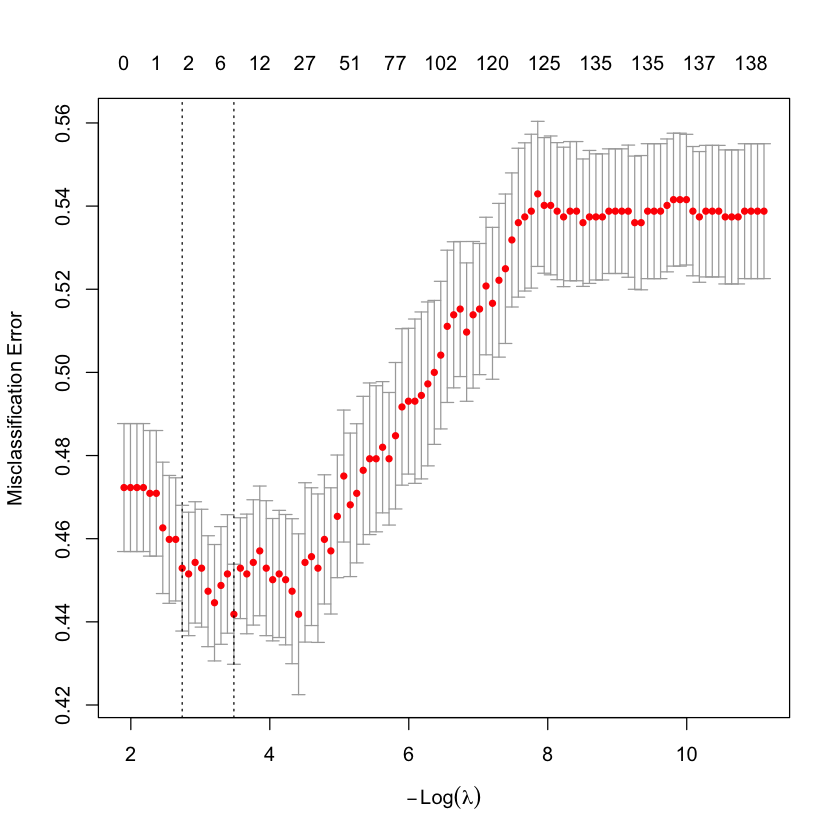

In [36]:
# ============================================================
# Step 5.2: Cross Validation Curve
# ============================================================

plot(cv_fit_combined)

abline(v = log(cv_fit_combined$lambda.min),
       col = "red",
       lty = 2)

abline(v = log(cv_fit_combined$lambda.1se),
       col = "blue",
       lty = 2)

In [37]:
# ============================================================
# Step 5.3: Best Lambda
# ============================================================

cv_fit_combined$lambda.min

cv_fit_combined$lambda.1se

[1] 0.03070489

[1] 0.06463086

In [38]:
# ============================================================
# Step 5.4: Number of Selected Features
# ============================================================

lasso_coef <- coef(
  cv_fit_combined,
  s = "lambda.1se"
)

selected_features <- lapply(
  lasso_coef,
  function(x) sum(x[-1, 1] != 0)
)

selected_features

sum(unlist(selected_features))

$CN
[1] 3

$MCI
[1] 1

$Converter
[1] 0

$AD
[1] 3

[1] 7

### Step 5 Summary

A multinomial LASSO model was successfully fit using both cortical thickness and intrinsic neural timescale (INT) features.

Cross-validation selected an optimal regularization parameter of λ = 0.0646 (lambda.1se), resulting in a sparse model containing only seven non-zero coefficients across the four diagnostic classes.

Interestingly, no features were uniquely selected for the Converter class, suggesting that converters continue to exhibit characteristics overlapping with both MCI and AD rather than forming a clearly distinct diagnostic category. This observation is consistent with previous analyses and supports the hypothesis that converters represent a transitional disease stage.

# Step 6: Evaluate Model Performance

After fitting the combined multinomial LASSO model, predictions are generated for the independent test dataset.

Model performance is evaluated using a confusion matrix and several classification metrics, including:

- Overall accuracy
- Cohen's Kappa
- Sensitivity
- Specificity

These results will later be compared with the cortical thickness-only and INT-only models to determine whether combining structural and functional MRI improves diagnostic prediction.

In [39]:
# ============================================================
# Step 6.1: Predict Test Set
# ============================================================

pred_combined <- predict(
  cv_fit_combined,
  newx = x_test,
  s = "lambda.1se",
  type = "class"
)

head(pred_combined)

lambda.1se
CN
CN
CN
CN
CN
CN


In [40]:
# ============================================================
# Step 6.2: Confusion Matrix
# ============================================================

confusionMatrix(
  factor(pred_combined, levels = levels(y_test)),
  y_test
)

Confusion Matrix and Statistics

           Reference
Prediction  CN MCI Converter AD
  CN        95  50         9 14
  MCI        0   0         0  0
  Converter  0   0         0  0
  AD         0   2         2  7

Overall Statistics
                                          
               Accuracy : 0.5698          
                 95% CI : (0.4939, 0.6435)
    No Information Rate : 0.5307          
    P-Value [Acc > NIR] : 0.1652          
                                          
                  Kappa : 0.1304          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: CN Class: MCI Class: Converter Class: AD
Sensitivity             1.0000     0.0000          0.00000   0.33333
Specificity             0.1310     1.0000          1.00000   0.97468
Pos Pred Value          0.5655        NaN              NaN   0.63636
Neg Pred Value          1.0000     0.7095          0.93855   0.91667
Prevalence 

In [41]:
cm_combined <- confusionMatrix(
  factor(pred_combined, levels = levels(y_test)),
  y_test
)

cm_combined

Confusion Matrix and Statistics

           Reference
Prediction  CN MCI Converter AD
  CN        95  50         9 14
  MCI        0   0         0  0
  Converter  0   0         0  0
  AD         0   2         2  7

Overall Statistics
                                          
               Accuracy : 0.5698          
                 95% CI : (0.4939, 0.6435)
    No Information Rate : 0.5307          
    P-Value [Acc > NIR] : 0.1652          
                                          
                  Kappa : 0.1304          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: CN Class: MCI Class: Converter Class: AD
Sensitivity             1.0000     0.0000          0.00000   0.33333
Specificity             0.1310     1.0000          1.00000   0.97468
Pos Pred Value          0.5655        NaN              NaN   0.63636
Neg Pred Value          1.0000     0.7095          0.93855   0.91667
Prevalence 

In [42]:
# ============================================================
# Step 6.4: Performance Metrics
# ============================================================

cm_combined$overall

cm_combined$byClass

Accuracy          Kappa  AccuracyLower  AccuracyUpper   AccuracyNull 
     0.5698324      0.1304101      0.4938617      0.6434513      0.5307263 
AccuracyPValue  McnemarPValue 
     0.1651774            NaN

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: CN,1.0000000,0.1309524,0.5654762,1.0000000,0.5654762,1.0000000,0.7224335,0.53072626,0.53072626,0.93854749,0.5654762
Class: MCI,0.0000000,1.0000000,NaN,0.7094972,NA,0.0000000,NA,0.29050279,0.00000000,0.00000000,0.5000000
Class: Converter,0.0000000,1.0000000,NaN,0.9385475,NA,0.0000000,NA,0.06145251,0.00000000,0.00000000,0.5000000
Class: AD,0.3333333,0.9746835,0.6363636,0.9166667,0.6363636,0.3333333,0.4375000,0.11731844,0.03910615,0.06145251,0.6540084


In [43]:
combined_results <- data.frame(
  Accuracy = cm_combined$overall["Accuracy"],
  Kappa = cm_combined$overall["Kappa"]
)

combined_results

,Accuracy,Kappa
,<dbl>,<dbl>
Accuracy,0.5698324,0.1304101


In [44]:
prediction_results <- data.frame(
  Subject = test_data$subject,
  True = y_test,
  Predicted = pred_combined
)

head(prediction_results)

,Subject,True,lambda.1se
,<chr>,<fct>,<chr>
1,002S0295X20110602,CN,CN
2,002S2043X20110916,MCI,CN
3,002S4219X20111215,MCI,CN
4,002S4654X20120405,MCI,CN
5,002S6103X20171120,CN,CN
6,003S5130X20191206,MCI,CN


# Step 7: Evaluate the Combined Model at `lambda.min`

The previous evaluation used `lambda.1se`, which selects a simpler and more strongly regularized model.

Because this conservative model predicted nearly all participants as CN, the combined model is also evaluated at `lambda.min`.

`lambda.min` is the regularization value that produced the lowest cross-validated classification error. It generally retains more predictors and may provide better discrimination between the four diagnostic groups, although it can also increase the risk of overfitting.

In [45]:
# ============================================================
# Step 7.1: Generate combined-model predictions at lambda.min
# ============================================================

pred_combined_min <- predict(
  cv_fit_combined,
  newx = x_test,
  s = "lambda.min",
  type = "class"
)

head(pred_combined_min)

lambda.min
CN
MCI
CN
MCI
CN
CN


In [46]:
# ============================================================
# Step 7.2: Evaluate predictions at lambda.min
# ============================================================

cm_combined_min <- confusionMatrix(
  factor(
    pred_combined_min,
    levels = levels(y_test)
  ),
  y_test
)

cm_combined_min

Confusion Matrix and Statistics

           Reference
Prediction  CN MCI Converter AD
  CN        92  46         7 10
  MCI        2   4         0  1
  Converter  0   0         0  0
  AD         1   2         4 10

Overall Statistics
                                          
               Accuracy : 0.5922          
                 95% CI : (0.5164, 0.6649)
    No Information Rate : 0.5307          
    P-Value [Acc > NIR] : 0.05752         
                                          
                  Kappa : 0.2126          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: CN Class: MCI Class: Converter Class: AD
Sensitivity             0.9684    0.07692          0.00000   0.47619
Specificity             0.2500    0.97638          1.00000   0.95570
Pos Pred Value          0.5935    0.57143              NaN   0.58824
Neg Pred Value          0.8750    0.72093          0.93855   0.93210
Prevalence 

In [47]:
# ============================================================
# Step 7.3: Compare lambda.1se and lambda.min
# ============================================================

combined_lambda_comparison <- data.frame(
  Lambda = c(
    "lambda.1se",
    "lambda.min"
  ),

  Accuracy = c(
    unname(cm_combined$overall["Accuracy"]),
    unname(cm_combined_min$overall["Accuracy"])
  ),

  Kappa = c(
    unname(cm_combined$overall["Kappa"]),
    unname(cm_combined_min$overall["Kappa"])
  )
)

combined_lambda_comparison

Lambda,Accuracy,Kappa
<chr>,<dbl>,<dbl>
lambda.1se,0.5698324,0.1304101
lambda.min,0.5921788,0.2125942


In [48]:
# ============================================================
# Step 7.4: Compare prediction distributions
# ============================================================

table(
  Lambda_1se = factor(
    pred_combined,
    levels = levels(y_test)
  )
)

table(
  Lambda_min = factor(
    pred_combined_min,
    levels = levels(y_test)
  )
)

Lambda_1se
       CN       MCI Converter        AD 
      168         0         0        11 

Lambda_min
       CN       MCI Converter        AD 
      155         7         0        17 

### Step 7 Interpretation

The combined cortical thickness + INT model performed better at `lambda.min` than at the more conservative `lambda.1se`.

At `lambda.min`, overall accuracy increased from 57.0% to 59.2%, while Cohen's Kappa increased from 0.130 to 0.213. The model also began predicting a small number of MCI participants rather than restricting predictions almost entirely to CN and AD.

However, performance remained highly unbalanced across classes. The model correctly identified 96.8% of CN participants and 47.6% of AD participants, but only 7.7% of MCI participants and none of the Converter participants. Among the 11 true Converters, seven were classified as CN and four as AD.

Therefore, `lambda.min` provides better overall discrimination than `lambda.1se`, but the combined sparse model still does not adequately distinguish the four diagnostic groups. The overall accuracy is primarily driven by recognition of the majority CN class rather than balanced performance across diagnosis.

# Step 8: Identify Selected Cortical Thickness and INT Features

The combined model contains both cortical thickness and INT predictors. To determine whether INT contributes information beyond cortical thickness, the nonzero LASSO coefficients are extracted and classified by imaging modality.

Features ending in `_thickness` are labeled as cortical thickness predictors. All other regional imaging variables are labeled as INT predictors.

Because `lambda.min` produced better test-set performance than `lambda.1se`, the selected features at `lambda.min` are examined first.

In [49]:
# ============================================================
# Step 8.1: Extract nonzero coefficients at lambda.min
# ============================================================

coef_combined_min <- coef(
  cv_fit_combined,
  s = "lambda.min"
)

extract_nonzero_features <- function(coef_matrix, class_name) {

  data.frame(
    Feature = rownames(coef_matrix),
    Coefficient = as.numeric(coef_matrix[, 1]),
    Class = class_name,
    row.names = NULL
  ) %>%
    filter(
      Feature != "(Intercept)",
      Coefficient != 0
    )
}

selected_combined_min <- bind_rows(
  lapply(
    names(coef_combined_min),
    function(class_name) {
      extract_nonzero_features(
        coef_combined_min[[class_name]],
        class_name
      )
    }
  )
) %>%
  mutate(
    Modality = if_else(
      str_detect(Feature, "_thickness$"),
      "Cortical Thickness",
      "INT"
    )
  ) %>%
  arrange(
    Class,
    desc(abs(Coefficient))
  )

selected_combined_min

Feature,Coefficient,Class,Modality
<chr>,<dbl>,<chr>,<chr>
lh_inferiorparietal_thickness,-1.02462420,AD,Cortical Thickness
lh_entorhinal_thickness,-0.87786891,AD,Cortical Thickness
rh_entorhinal_thickness,-0.51993651,AD,Cortical Thickness
rh_parahippocampal_thickness,-0.40745748,AD,Cortical Thickness
rh_inferiorparietal_thickness,-0.30764273,AD,Cortical Thickness
rh_parstriangularis_thickness,0.28259700,AD,Cortical Thickness
rh_cuneus_thickness,1.01174320,CN,Cortical Thickness
lh_superiortemporal_thickness,0.92226487,CN,Cortical Thickness
lh_entorhinal_thickness,0.71043523,CN,Cortical Thickness


In [50]:
# ============================================================
# Step 8.2: Count selected features by modality and class
# ============================================================

selected_combined_min %>%
  count(Modality)

selected_combined_min %>%
  count(Class, Modality)

Modality,n
<chr>,<int>
Cortical Thickness,26
INT,8


Class,Modality,n
<chr>,<chr>,<int>
AD,Cortical Thickness,6
CN,Cortical Thickness,13
CN,INT,2
Converter,Cortical Thickness,3
MCI,Cortical Thickness,4
MCI,INT,6


In [51]:
# ============================================================
# Step 8.3: Number of selected features per class
# ============================================================

selected_combined_min %>%
  count(Class)

Class,n
<chr>,<int>
AD,6
CN,15
Converter,3
MCI,10


### Step 8 Interpretation

The combined model retained 34 nonzero predictors at `lambda.min`, including 26 cortical thickness variables and 8 INT variables.

Cortical thickness remained the dominant imaging modality, accounting for approximately three quarters of all selected predictors. However, several INT features survived LASSO regularization, indicating that functional measurements contribute additional information beyond structural MRI.

Interestingly, the contribution of INT differed across diagnostic groups. The AD class relied exclusively on cortical thickness features, whereas the MCI class retained six INT predictors and only four cortical thickness predictors. This suggests that functional brain dynamics may provide complementary information during earlier disease stages, while structural atrophy becomes more dominant in established Alzheimer's disease.

No INT predictors were retained for the Converter class. One possible explanation is that the structural cortical thickness measurements already capture much of the discriminative information available for this small group, although the limited number of Converter participants may also reduce the stability of feature selection.

# Step 9: Fit Single-Modality Models Using the Same Data Split

To determine whether INT improves prediction beyond cortical thickness, cortical thickness-only and INT-only models are fit using the same participants and the same stratified train-test split as the combined model.

This creates a fair comparison because all three models use:

- identical training and testing participants
- the same four diagnostic groups
- the same multinomial LASSO method
- the same 10-fold cross-validation procedure
- `lambda.min` for test-set evaluation

The three models are:

1. Cortical thickness only: 68 predictors
2. INT only: 84 predictors
3. Combined cortical thickness + INT: 152 predictors

In [52]:
# ============================================================
# Step 9.1: Identify CT and INT feature columns
# ============================================================

ct_columns <- names(combined_data)[
  str_detect(
    names(combined_data),
    "_thickness$"
  )
]

int_columns <- setdiff(
  names(combined_data),
  c(
    "subject",
    "group",
    ct_columns
  )
)

length(ct_columns)
length(int_columns)

head(ct_columns)
head(int_columns)

[1] 68

[1] 84

[1] "lh_bankssts_thickness"               
[2] "lh_caudalanteriorcingulate_thickness"
[3] "lh_caudalmiddlefrontal_thickness"    
[4] "lh_cuneus_thickness"                 
[5] "lh_entorhinal_thickness"             
[6] "lh_fusiform_thickness"

[1] "Left-Thalamus"    "Left-Caudate"     "Left-Putamen"     "Left-Pallidum"   
[5] "Left-Hippocampus" "Left-Amygdala"

In [53]:
# ============================================================
# Step 9.2: Create CT-only and INT-only matrices
# ============================================================

x_train_CT <- train_data %>%
  select(all_of(ct_columns)) %>%
  as.matrix()

x_test_CT <- test_data %>%
  select(all_of(ct_columns)) %>%
  as.matrix()

x_train_INT <- train_data %>%
  select(all_of(int_columns)) %>%
  as.matrix()

x_test_INT <- test_data %>%
  select(all_of(int_columns)) %>%
  as.matrix()

dim(x_train_CT)
dim(x_test_CT)

dim(x_train_INT)
dim(x_test_INT)

[1] 722  68

[1] 179  68

[1] 722  84

[1] 179  84

In [54]:
# ============================================================
# Step 9.3: Fit CT-only multinomial LASSO
# ============================================================

set.seed(123)

cv_fit_CT <- cv.glmnet(
  x = x_train_CT,
  y = y_train,
  family = "multinomial",
  alpha = 1,
  nfolds = 10,
  type.measure = "class"
)

cv_fit_CT$lambda.min
cv_fit_CT$lambda.1se

[1] 0.007605837

[1] 0.04059006